# Openness and Closeness in Seabed Morphological Mapping

**Context:** This notebook explains the concepts of *topographic openness* and *closeness* as used in the GA-SaMMT (Geoscience Australia's Semi-automated Morphological Mapping Tools) for characterising seabed features from bathymetric data.

**References:**
- Yokoyama, R., Shirasawa, M., & Pike, R. J. (2002). Visualizing topography by openness: A new application of image processing to digital elevation models. *Photogrammetric Engineering and Remote Sensing*, 68(3), 257–265.
- Huang, Z., Nanson, R., McNeil, M., Wenderlich, M., Gafeira, J., Post, A, Nichol, S. (2023). Rule-based semi-automated tools for mapping seabed morphology from bathymetry data. *Frontiers in Marine Science*, 10, 1236788.

---

## 1. What is Topographic Openness?

**Topographic openness** is a terrain attribute that quantifies how *open* or *enclosed* a location is relative to its surrounding landscape. It was introduced by Yokoyama et al. (2002) originally for land topography, and has since been adapted for bathymetric (underwater) terrain analysis.

The concept is based on **zenith angles** — angles measured upward from a horizontal plane to the terrain surface along radial lines emanating from a central point.

For a given point on the terrain:
- We cast rays outward in multiple directions (typically 8 principal directions: N, NE, E, SE, S, SW, W, NW).
- Along each ray, we find the **maximum zenith angle** to the horizon (the steepest upward angle we can "see").
- We average these angles across all directions.

There are **two complementary measures**:

| Measure | Symbol | Intuition |
|---|---|---|
| **Positive Openness (PO)** | Ψ⁺ | How open is the sky above? High = open terrain (ridges, hills) |
| **Negative Openness (NO)** | Ψ⁻ | How enclosed is the terrain below? High = enclosed terrain (valleys, pits) |

## 2. Mathematical Definition

For a point $P$ on a digital elevation model (DEM) or bathymetric grid, consider $n$ radial directions (usually $n = 8$). For each direction $i$, we search along a line of length $L$ (the **search radius** in cell units).

### Positive Openness

For each direction $i$, find the **maximum elevation angle** $\alpha_i$ to any point along that radial line:

$$\alpha_i = \max_{d=1}^{L} \arctan\left(\frac{z(d) - z(P)}{d \cdot \Delta x}\right)$$

where:
- $z(d)$ = elevation at distance $d$ along the radial line
- $z(P)$ = elevation at the central point
- $\Delta x$ = grid cell size

The **Positive Openness** is:

$$\Psi^+ = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{\pi}{2} - \alpha_i\right)$$

This is the mean **zenith angle** — $90°$ minus the maximum elevation angle in each direction.

### Negative Openness

For each direction $i$, find the **minimum depression angle** $\beta_i$ (looking downward):

$$\beta_i = \max_{d=1}^{L} \arctan\left(\frac{z(P) - z(d)}{d \cdot \Delta x}\right)$$

The **Negative Openness** is:

$$\Psi^- = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{\pi}{2} - \beta_i\right)$$

> **Key insight:** Both openness values range from 0 to π/2 radians (0° to 90°). **Higher positive openness** → more exposed / convex terrain. **Lower negative openness** (or equivalently, higher closeness) → more enclosed / concave terrain.

## 3. Visual Intuition

The diagram below illustrates the zenith angle concept for a 2D cross-section. Imagine standing at point P and looking along a radial line:

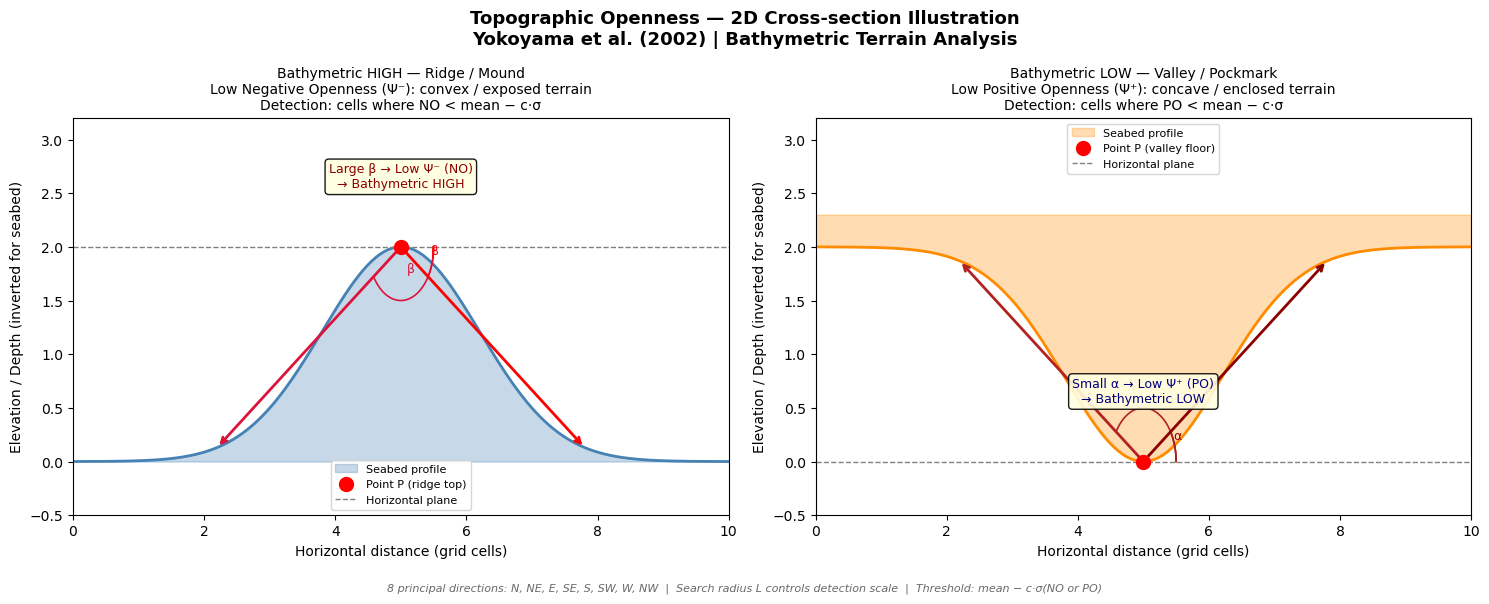

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# Topographic Openness — 2D Cross-section Illustration
# Yokoyama et al. (2002), adapted for bathymetric terrain
#
# BATHYMETRIC CONVENTION:
#   Bathymetric High (ridge/mound): LOW Negative Openness (NO)
#     → depression angles β large → Ψ⁻ small
#   Bathymetric Low (pockmark/valley): LOW Positive Openness (PO)
#     → zenith angles α small → Ψ⁺ small
#
# 8 principal directions collapsed to 2D: left & right rays
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Topographic Openness — 2D Cross-section Illustration\n"
    "Yokoyama et al. (2002) | Bathymetric Terrain Analysis",
    fontsize=13, fontweight='bold'
)

x = np.linspace(0, 10, 300)
ray_length = 2.8  # search radius L in grid units

def ridge(xi):
    """Bathymetric High — Gaussian bump"""
    return 2 * np.exp(-0.5 * ((xi - 5) / 1.2) ** 2)

def valley(xi):
    """Bathymetric Low — inverted Gaussian"""
    return -2 * np.exp(-0.5 * ((xi - 5) / 1.2) ** 2) + 2

# Helper: draw an arc showing the angle between horizontal and a ray
def draw_angle_arc(ax, cx, cz, dx, dz, radius, color, label, label_offset=(0.1, 0.1)):
    ray_angle = np.arctan2(dz, dx)
    horiz_angle = 0.0  # horizontal reference
    start = min(horiz_angle, ray_angle)
    end = max(horiz_angle, ray_angle)
    arc_angles = np.linspace(start, end, 40)
    arc_x = cx + radius * np.cos(arc_angles)
    arc_z = cz + radius * np.sin(arc_angles)
    ax.plot(arc_x, arc_z, color=color, lw=1.2, ls='-')
    mid = (start + end) / 2
    ax.text(cx + (radius + label_offset[0]) * np.cos(mid),
            cz + (radius + label_offset[1]) * np.sin(mid),
            label, color=color, fontsize=9, ha='center')

# ------------------------------------------------------------------
# LEFT: Bathymetric HIGH — Ridge / Mound
#   Low Negative Openness (Ψ⁻)
#   Depression angles β are LARGE → Ψ⁻ is SMALL
# ------------------------------------------------------------------
ax = axes[0]
z = ridge(x)
ax.fill_between(x, z, alpha=0.3, color='steelblue', label='Seabed profile')
ax.plot(x, z, color='steelblue', lw=2)

# Point P at ridge top
px, pz = 5.0, float(ridge(5.0))
ax.plot(px, pz, 'ro', ms=10, zorder=5, label='Point P (ridge top)')

# Horizontal reference line
ax.axhline(pz, color='gray', ls='--', lw=1, label='Horizontal plane')

# 8 directions → in 2D cross-section: left & right rays at equal spacing
# Directions: right = 0°, left = 180° (plus intermediate shown as offsets)
ray_dirs = [ray_length, -ray_length]  # right and left
ray_colors = ['red', 'crimson']
for rdx, col in zip(ray_dirs, ray_colors):
    ex = px + rdx
    ez = float(ridge(ex))
    # Arrow from P to surface horizon
    ax.annotate('', xy=(ex, ez), xytext=(px, pz),
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    # Depression angle arc (ray goes downward from P → β is angle below horizontal)
    draw_angle_arc(ax, px, pz, rdx, ez - pz, radius=0.5,
                   color=col, label='β', label_offset=(0.05, -0.25))

ax.text(5.0, pz + 0.55,
        "Large β → Low Ψ⁻ (NO)\n→ Bathymetric HIGH",
        color='darkred', fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 3.2)
ax.set_title(
    "Bathymetric HIGH — Ridge / Mound\n"
    "Low Negative Openness (Ψ⁻): convex / exposed terrain\n"
    "Detection: cells where NO < mean − c·σ",
    fontsize=10
)
ax.set_xlabel("Horizontal distance (grid cells)")
ax.set_ylabel("Elevation / Depth (inverted for seabed)")
ax.legend(fontsize=8, loc='lower center')

# ------------------------------------------------------------------
# RIGHT: Bathymetric LOW — Valley / Pockmark
#   Low Positive Openness (Ψ⁺)
#   Zenith angles α are SMALL → Ψ⁺ is SMALL
# ------------------------------------------------------------------
ax2 = axes[1]
z2 = valley(x)
ax2.fill_between(x, z2, 2.3, alpha=0.3, color='darkorange', label='Seabed profile')
ax2.plot(x, z2, color='darkorange', lw=2)

# Point P at valley floor
px2, pz2 = 5.0, float(valley(5.0))
ax2.plot(px2, pz2, 'ro', ms=10, zorder=5, label='Point P (valley floor)')
ax2.axhline(pz2, color='gray', ls='--', lw=1, label='Horizontal plane')

# Left & right rays rising up the valley walls
ray_colors2 = ['darkred', 'firebrick']
for rdx, col in zip(ray_dirs, ray_colors2):
    ex2 = px2 + rdx
    ez2 = float(valley(ex2))
    ax2.annotate('', xy=(ex2, ez2), xytext=(px2, pz2),
                 arrowprops=dict(arrowstyle='->', color=col, lw=2))
    # Zenith angle arc (ray goes upward from P → α is angle above horizontal)
    draw_angle_arc(ax2, px2, pz2, rdx, ez2 - pz2, radius=0.5,
                   color=col, label='α', label_offset=(0.05, 0.2))

ax2.text(5.0, pz2 + 0.55,
         "Small α → Low Ψ⁺ (PO)\n→ Bathymetric LOW",
         color='navy', fontsize=9, ha='center',
         bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax2.set_xlim(0, 10)
ax2.set_ylim(-0.5, 3.2)
ax2.set_title(
    "Bathymetric LOW — Valley / Pockmark\n"
    "Low Positive Openness (Ψ⁺): concave / enclosed terrain\n"
    "Detection: cells where PO < mean − c·σ",
    fontsize=10
)
ax2.set_xlabel("Horizontal distance (grid cells)")
ax2.set_ylabel("Elevation / Depth (inverted for seabed)")
ax2.legend(fontsize=8, loc='upper center')

# Footer
fig.text(0.5, 0.01,
         "8 principal directions: N, NE, E, SE, S, SW, W, NW  |  "
         "Search radius L controls detection scale  |  "
         "Threshold: mean − c·σ(NO or PO)",
         ha='center', fontsize=8, color='dimgray', style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 4. Relationship Between Openness and Seabed Features

Because bathymetric data records **depth** (values increase downward), the openness measures behave in a specific way:

### Bathymetric Highs (seamounts, ridges, mounds, hummocks)

A bathymetric high is a location **shallower** than its surroundings — a "bump" in the seabed.

- **Negative Openness (NO)** is **small** at a bathymetric high.
  - Why? Looking outward from the top of a mound, the surrounding terrain drops away. The depression angles are large → negative openness is small.
  - In the GA-SaMMT openness tool, **negative openness is used to detect bathymetric highs** — regions with NO below a threshold are classified as high features.

### Bathymetric Lows (pockmarks, valleys, canyons, depressions)

A bathymetric low is a location **deeper** than its surroundings — a "pit" or "valley".

- **Positive Openness (PO)** is **small** at a bathymetric low.
  - Why? At the bottom of a pit, the surrounding terrain rises steeply. The zenith angles are small → positive openness is small.
  - In the GA-SaMMT openness tool, **positive openness is used to detect bathymetric lows** — regions with PO below a threshold are classified as low features.

Summary table:

| Feature type | Positive Openness (PO) | Negative Openness (NO) | Detection metric |
|---|---|---|---|
| **Bathymetric High** (ridge, mound) | High | **Low** | Low NO |
| **Flat seabed** | Medium | Medium | Neither |
| **Bathymetric Low** (pit, canyon) | **Low** | High | Low PO |

## 5. The Openness Circle Radius Parameter

The **search radius** $L$ (called *Openness Circle Radius* in GA-SaMMT, measured in grid cell units) controls the **spatial scale** of the features being detected.

- **Small radius** (e.g., 10 cells) → sensitive to **fine-scale** features (small hummocks, micro-pockmarks)
- **Large radius** (e.g., 100 cells) → sensitive to **broad-scale** features (seamounts, large canyons)

This is analogous to the TPI (Topographic Position Index) radius parameter — it sets the neighbourhood window over which "context" is evaluated.

**Practical tip:** Run the tool at multiple radii and merge results to capture features at different scales.

## 6. Thresholding: How Features are Extracted

Once the NO or PO raster is computed, GA-SaMMT applies a **threshold** to identify candidate feature cells:

For **Bathymetric Highs** (using NO):
$$\text{NO\_threshold} = \overline{\text{NO}} - c \cdot \sigma_{\text{NO}}$$

- Cells where $\text{NO} < \text{NO\_threshold}$ are candidate high-feature cells.
- Parameter $c$ corresponds to the **NO STD Scale Large** parameter in the tool (e.g., $c = 1.0$ means the threshold is 1 standard deviation below the mean).
- A second, smaller threshold (**NO STD Scale Small**, e.g., $c = 0$) is used to capture the "tops" of the features more precisely.

For **Bathymetric Lows** (using PO):
$$\text{PO\_threshold} = \overline{\text{PO}} - c \cdot \sigma_{\text{PO}}$$

- Cells where $\text{PO} < \text{PO\_threshold}$ are candidate low-feature cells.

After thresholding, a minimum **area threshold** is applied to remove noise polygons that are too small to represent meaningful features.

## 7. Comparison with TPI (Topographic Position Index)

GA-SaMMT offers both TPI-based and Openness-based methods. Understanding their differences helps choose the right tool:

| Property | TPI | Openness |
|---|---|---|
| **What it measures** | Difference between a cell's elevation and the mean of its neighbourhood | Angular openness of the terrain from a point |
| **Computation** | Fast (mean filter) | Slower (8-direction ray casting) |
| **Sensitivity** | Linear differences in depth | Angular shape of terrain — better for asymmetric or complex features |
| **Best for** | General morphology, large datasets | Features with strong local curvature (pockmarks, volcanic cones) |
| **Scale control** | Radius of neighbourhood window | Search radius for ray casting |

The two methods are **complementary** — in practice, running both and comparing results (or combining outputs) gives the most robust feature detection.

## 8. Summary and Key Takeaways

| Concept | Definition | Key use |
|---|---|---|
| **Positive Openness (PO)** | Mean zenith angle to the highest point in each radial direction | Small PO → bathymetric low (pockmark, valley) |
| **Negative Openness (NO)** | Mean zenith angle to the lowest point in each radial direction | Small NO → bathymetric high (mound, ridge) |
| **Search radius** | Controls spatial scale of detection | Small radius = fine features; large radius = broad features |
| **STD threshold** | `mean - c×std` applied to NO or PO | Adjusting `c` controls sensitivity |

### Practical workflow in GA-SaMMT

1. **Compute** NO or PO from bathymetric grid (`BathymetricHigh.pyt` or `BathymetricLow.pyt`).
2. **Threshold** the raster using `mean - c × std` to create a binary mask of candidate cells.
3. **Vectorise** the mask into polygons.
4. **Filter** by minimum area threshold (removes noise).
5. **Add attributes** (shape, topographic, profile) using `AddAttributes.pyt`.
6. **Classify** each polygon into a morphological type (mound, ridge, pockmark, etc.) using `ClassificationFeature.pyt`.

### Openness vs. TPI: when to use which?

- Use **TPI** when working with large datasets and speed matters, or when features are broadly defined by local relief.
- Use **Openness** when features have a strong angular geometry (circular pits, conical mounds), or when the terrain has complex asymmetric shapes.
- **Combine both** for maximum robustness — the GA-SaMMT `TPI LMI` tool also combines TPI with Local Moran's I for an additional spatial autocorrelation filter.

# GA-SaMMT Topographic Openness Pipeline: Steps 1 to 12

This section outlines the complete structural progression of the **GA-SaMMT Geomorphic Mapping Algorithm**. The pipeline is organized into four distinct execution phases that systematically transform raw digital elevation grids into validated, presentation-grade vector landform polygons.

---

## Pipeline Architecture Overview

### ─── PHASE I: DATA INGESTION ───

* **[Step 1: Ingest Raster]** ───> Load multi-beam GeoTIFF, mask NoData, and invert values to enforce positive elevation ($Z$).
    * │
    * ▼
* **[Step 2: Ray Casting]** ───> Run line-of-sight analysis in 8 compass paths. Generate Positive ($PO$) & Negative Openness ($NO$) grids scaled from $0^\circ \text{ to } 180^\circ$.
    * │
    * ▼

### ─── PHASE II: SEEDING & STATISTICAL ZONING ───

* │
    * ▼
* **[Step 3: Track Seeds]** ───> Pick channel ($NO$ for Highs, $PO$ for Lows). Run local focal filters to spot peak/pit points.
    * │
    * ▼
* **[Step 4: Statistics]** ───> Calculate global mean ($\mu$) and standard deviation ($\sigma$) across the chosen openness grid.
    * │
    * ▼
* **[Step 5: Thresholding]** ───> Evaluate $T = \mu - (C \cdot \sigma)$ using Large/Small coefficients to pinpoint precise geometric breaklines.
    * │
    * ▼

### ─── PHASE III: EXTRACTION & VECTORIZATION ───

* │
    * ▼
* **[Step 6: Binary Masks]** ───> Apply thresholds to turn continuous pixel grids into two boolean layers ($M_{large}$ and $M_{small}$).
    * │
    * ▼
* **[Step 7: Check Hierarchy]** ───> Scan mask grid weights to assign the tightest area as the "strict" layer and the broader area as "loose".
    * │
    * ▼
* **[Step 8: Polygonization]** ───> Trace pixel boundaries to convert raster shapes into Shapely vector polygon layers.
    * │
    * ▼
* **[Step 9: Seed Pruning]** ───> Overlay shapes with Step 3 seeds. Discard background noise shapes that lack a valid structural peak/pit.
    * │
    * ▼

### ─── PHASE IV: OVERLAY LOGIC & REFINEMENT ───

* │
    * ▼
* **[Step 10: Scale Blending]** ───> Overlay strict cores onto loose boundaries. Split multi-peak blobs; expand single-core footprints.
    * │
    * ▼
* **[Step 11: Geometry Clean]** ───> Run a zero-width buffer to mend open loops, purge duplicate overlaps, and enforce the minimum area filter ($\text{area} \ge A_T$).
    * │
    * ▼
* **[Step 12: Lock Outputs]** ───> Bind final validated vector loops to active standard memory ($P_{final}$, $O$) for immediate dual-color map plotting.

---

## Processing Phase Summaries

* **Phase I (Steps 1–2):** Takes raw marine bathymetry arrays, aligns the vertical orientation convention, and computes regional exposure metrics using long-range ray casting equations.
* **Phase II (Steps 3–5):** Isolates key feature anchors (peaks or pits) and evaluates global standard deviation offsets to automatically establish the boundary thresholds for structural shapes.
* **Phase III (Steps 6–9):** Converts continuous raster grids into independent boolean masks, runs vector-tracing loops to produce geospatial polygons, and throws out background noise that lacks a core landform seed.
* **Phase IV (Steps 10–12):** Blends strict and loose boundaries to correctly segment complex landforms, runs automated geometric cleanup code, and binds the final outputs to active memory for high-contrast mapping.

## Gifford Bathymetric TIF

Executing Step 1: Loading raw GeoTIFF container -> gifford_bathy.tif
Executing Step 2: Calculating PO and NO matrices concurrently across 8 directions...
Processing Steps 3-12 for Bathymetric High Features (NO Channel)...
Processing Steps 3-12 for Bathymetric Low Features (PO Channel)...

GA-SAMMT STRUCTURAL WORKFLOW SEGMENTATION COMPLETE
Total Computation Runtime:              73.66s
Final Mapped High Features (Plateau):   55 Polygons
Final Mapped Low Features (Canyons):    86 Polygons
Generating continuous Openness raster plot with dual contrasting outlines...


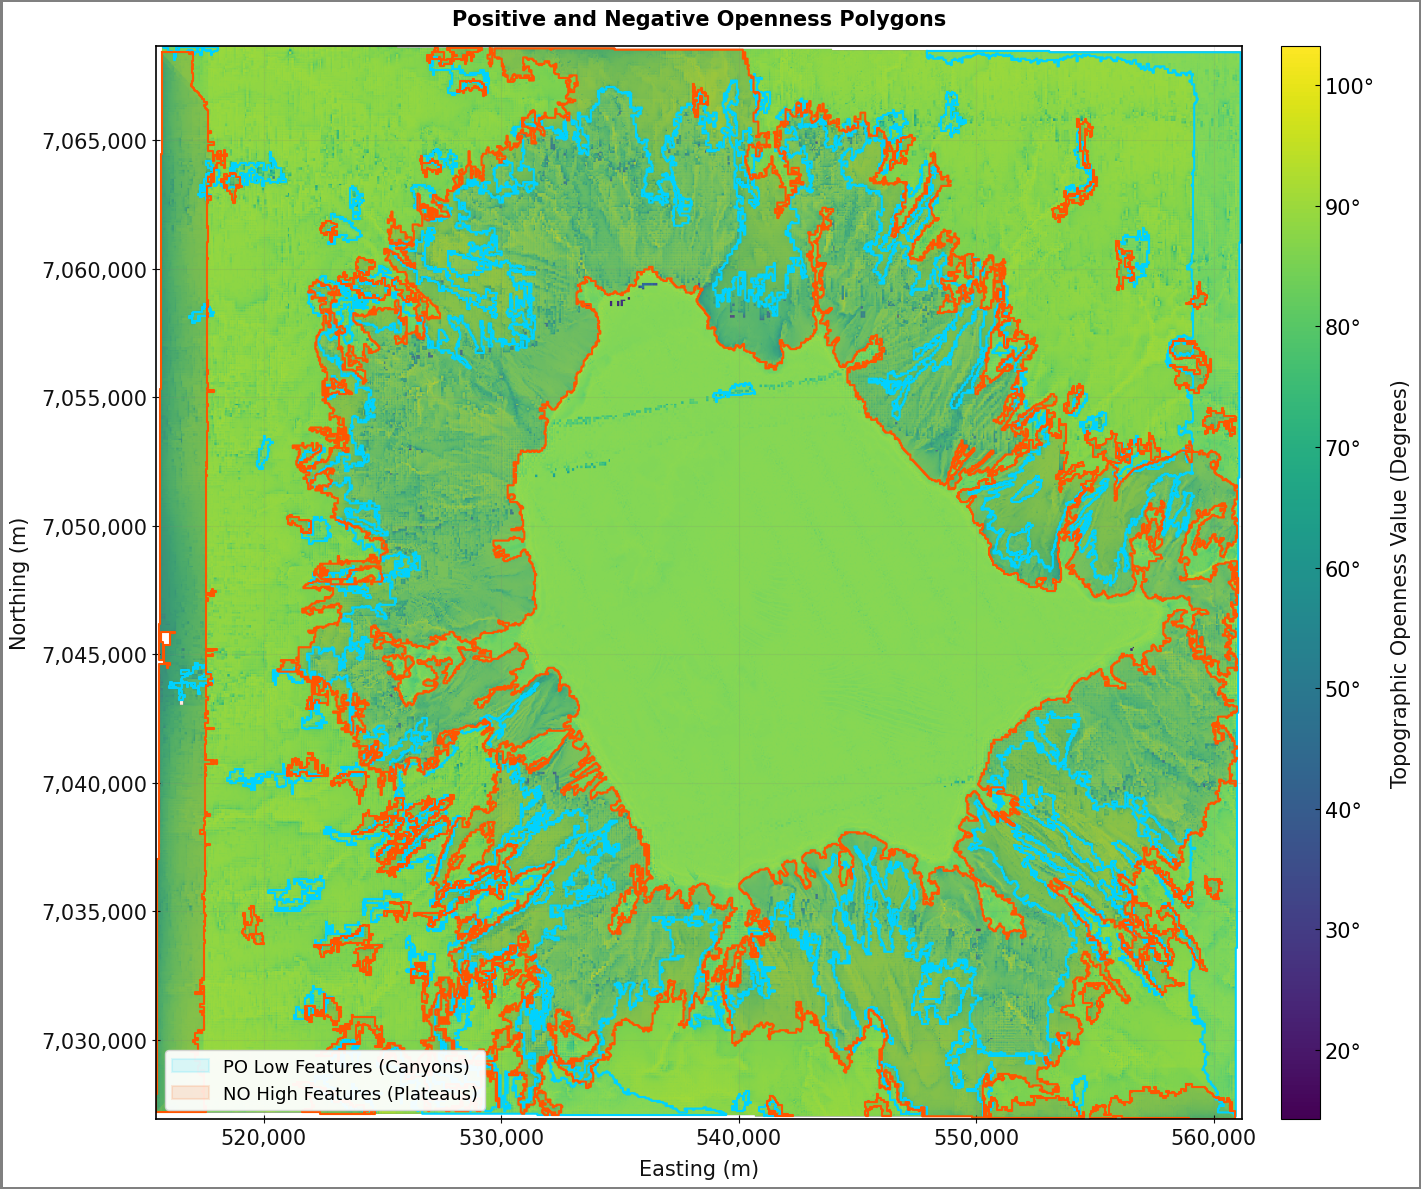

In [5]:
import os
import time
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import rasterio
from rasterio import features
from scipy.ndimage import maximum_filter, minimum_filter
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union

# =====================================================================
# SYSTEM INITIALIZATION & GLOBAL PARAMETERS
# =====================================================================
current_working_dir = Path.cwd()
if current_working_dir.name == "notebooks":
    GIFFORD_PATH = current_working_dir.parent / "data" / "gifford_bathy.tif"
else:
    GIFFORD_PATH = current_working_dir / "data" / "gifford_bathy.tif"

if not GIFFORD_PATH.exists():
    for parent in current_working_dir.parents:
        check_path = parent / "data" / "gifford_bathy.tif"
        if check_path.exists():
            GIFFORD_PATH = check_path
            break
            
if not GIFFORD_PATH.exists():
    raise FileNotFoundError(f"Could not locate gifford_bathy.tif at: {GIFFORD_PATH.absolute()}")

# Morphological optimization parameters
RADIUS_CELLS = 45          # Lookup horizon (45 cells = 2250 meters)
C_LARGE = -0.15            # Large scale multiplier parameter
C_SMALL = 0.0              # Small scale multiplier parameter
AREA_THRESHOLD = 250000.0  # Minimum vector polygon size filter (0.25 sq km)


# =====================================================================
# STEP 1: LOAD RASTER & INITIALIZE SPATIAL METADATA
# =====================================================================
print(f"Executing Step 1: Loading raw GeoTIFF container -> {GIFFORD_PATH.name}")
with rasterio.open(str(GIFFORD_PATH)) as src:
    B_raw = src.read(1)
    tif_profile = src.meta.copy()
    cell_size = src.transform[0]
    nodata_val = src.nodatavals[0]
    
    Z_grid = np.where(B_raw == nodata_val, np.nan, B_raw.astype(float)) if nodata_val is not None else B_raw.astype(float)

# Enforce standard elevation-positive-up convention
Z_grid = -Z_grid  

compass_definitions = {
    "N":  (-1,  0), "NE": (-1,  1), "E":  ( 0,  1), "SE": ( 1,  1),
    "S":  ( 1,  0), "SW": ( 1, -1), "W":  ( 0, -1), "NW": (-1, -1)
}

geometry_meta = {}
for direction, (dr, dc) in compass_definitions.items():
    steps = np.arange(1, RADIUS_CELLS + 1)
    row_offsets = dr * steps
    col_offsets = dc * steps
    step_multiplier = np.sqrt(dr**2 + dc**2)
    distances = steps * cell_size * step_multiplier
    
    geometry_meta[direction] = {
        "row_offsets": row_offsets, "col_offsets": col_offsets, "distances": distances
    }


# =====================================================================
# STEP 2: DUAL-CHANNEL VECTORIZED RAY CASTING ENGINE (0-180 SCALE)
# =====================================================================
print("Executing Step 2: Calculating PO and NO matrices concurrently across 8 directions...")
global_start_time = time.time()
rows, cols = Z_grid.shape
max_gamma_all_dirs, min_gamma_all_dirs = [], []

for direction, geom in geometry_meta.items():
    gamma_steps = np.full((RADIUS_CELLS, rows, cols), np.nan)
    
    for step_idx in range(RADIUS_CELLS):
        dr, dc, dist = geom["row_offsets"][step_idx], geom["col_offsets"][step_idx], geom["distances"][step_idx]
        Z_shifted = np.roll(Z_grid, shift=(-dr, -dc), axis=(0, 1))
        
        # Boundary Edge Buffer Isolation
        boundary_mask = np.ones((rows, cols), dtype=bool)
        if dr > 0: boundary_mask[:dr, :] = False
        if dr < 0: boundary_mask[dr:, :] = False
        if dc > 0: boundary_mask[:, :dc] = False
        if dc < 0: boundary_mask[:, dc:] = False
        Z_shifted[~boundary_mask] = np.nan
        
        gamma_steps[step_idx] = np.arctan((Z_shifted - Z_grid) / dist)
        
    with np.errstate(all='ignore'):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            max_gamma_dir = np.nanmax(gamma_steps, axis=0)
            min_gamma_dir = np.nanmin(gamma_steps, axis=0)
        
    max_gamma_dir[np.isnan(max_gamma_dir)] = 0.0
    min_gamma_dir[np.isnan(min_gamma_dir)] = 0.0
    max_gamma_all_dirs.append(max_gamma_dir)
    min_gamma_all_dirs.append(min_gamma_dir)
    
mean_max_gamma = np.mean(np.stack(max_gamma_all_dirs, axis=0), axis=0)
mean_min_gamma = np.mean(np.stack(min_gamma_all_dirs, axis=0), axis=0)

# Implement traditional Yokoyama 0 to 180-degree mathematical conversion bounds
PO_grid = np.degrees((np.pi / 2.0) - mean_max_gamma)
NO_grid = np.degrees((np.pi / 2.0) + mean_min_gamma)

nan_mask = np.isnan(Z_grid)
PO_grid[nan_mask], NO_grid[nan_mask] = np.nan, np.nan


# =====================================================================
# PIPELINE ENCAPSULATION ROUTINE: STEPS 3 TO 12
# =====================================================================
def run_sa_mmt_segmentation(O_channel, target_mode):
    footprint = np.ones((5, 5), dtype=bool)
    
    # ---------------------------------------------------------------------
    # Step 3: Select target channel and local extrema type
    # ---------------------------------------------------------------------
    if target_mode == "high":
        local_max = maximum_filter(Z_grid, footprint=footprint, mode='constant', cval=np.nan)
        extrema = (Z_grid == local_max) & ~np.isnan(Z_grid)
    else:
        local_min = minimum_filter(Z_grid, footprint=footprint, mode='constant', cval=np.nan)
        extrema = (Z_grid == local_min) & ~np.isnan(Z_grid)
        
    # ---------------------------------------------------------------------
    # Steps 4 & 5: Calculate openness statistics and dual thresholds
    # ---------------------------------------------------------------------
    O_valid = O_channel[np.isfinite(O_channel)]
    mu = float(np.mean(O_valid))
    sigma = float(np.std(O_valid))
    T_large = mu - (C_LARGE * sigma)
    T_small = mu - (C_SMALL * sigma)
    
    # ---------------------------------------------------------------------
    # Step 6: Create two binary masks
    # ---------------------------------------------------------------------
    M_large = (O_channel < T_large) & ~np.isnan(O_channel)
    M_small = (O_channel < T_small) & ~np.isnan(O_channel)
    
    # ---------------------------------------------------------------------
    # Step 7: Determine strict and loose masks
    # ---------------------------------------------------------------------
    if np.sum(M_large) <= np.sum(M_small):
        M_strict, M_loose = M_large, M_small
    else:
        M_strict, M_loose = M_small, M_large
        
    # ---------------------------------------------------------------------
    # Step 8: Polygonise both masks
    # ---------------------------------------------------------------------
    def polygonise(mask):
        polygons = []
        for geojson_shape, _ in features.shapes(mask.astype(np.uint8), mask=mask, transform=tif_profile['transform']):
            geom = shape(geojson_shape)
            if not geom.is_valid: geom = geom.buffer(0)
            polygons.append(geom)
        return polygons

    P_strict_raw = polygonise(M_strict)
    P_loose_raw = polygonise(M_loose)
    
    # ---------------------------------------------------------------------
    # Step 9: Keep only polygons containing local extrema
    # ---------------------------------------------------------------------
    extrema_rows, extrema_cols = np.where(extrema)
    extrema_points = [shape({'type': 'Point', 'coordinates': tif_profile['transform'] * (col + 0.5, row + 0.5)}) 
                      for row, col in zip(extrema_rows, extrema_cols)]
    if not extrema_points: return [], O_channel
    extrema_collection = unary_union(extrema_points)
    
    P_strict = [P for P in P_strict_raw if P.intersects(extrema_collection)]
    P_loose = [Q for Q in P_loose_raw if Q.intersects(extrema_collection)]
    
    # ---------------------------------------------------------------------
    # Step 10: Overlay split/merge logic
    # ---------------------------------------------------------------------
    P_raw = []
    for Q in P_loose:
        contained = []
        for P in P_strict:
            if Q.contains(P): contained.append(P)
            elif Q.intersects(P):
                if Q.intersection(P).area / P.area > 0.5: contained.append(P)
        if len(contained) > 1: P_raw.extend(contained)
        elif len(contained) == 1: P_raw.append(Q)
        
    # ---------------------------------------------------------------------
    # Step 11: Clean geometries and remove small features
    # ---------------------------------------------------------------------
    P_cleaned = [P.buffer(0) if not P.is_valid else P for P in P_raw]
    
    P_unique = []
    for geom in P_cleaned:
        if not any(geom.equals(u) for u in P_unique): P_unique.append(geom)
        
    P_final = [P for P in P_unique if P.area >= AREA_THRESHOLD]
    
    # ---------------------------------------------------------------------
    # Step 12: Return outputs
    # ---------------------------------------------------------------------
    return P_final, O_channel


# =====================================================================
# PIPELINE EXECUTION ENGINE RUNS
# =====================================================================
print("Processing Steps 3-12 for Bathymetric High Features (NO Channel)...")
high_features, NO_out = run_sa_mmt_segmentation(NO_grid, target_mode="high")

print("Processing Steps 3-12 for Bathymetric Low Features (PO Channel)...")
low_features, PO_out = run_sa_mmt_segmentation(PO_grid, target_mode="low")

print("\n" + "="*60)
print("GA-SAMMT STRUCTURAL WORKFLOW SEGMENTATION COMPLETE")
print("="*60)
print(f"Total Computation Runtime:              {time.time() - global_start_time:.2f}s")
print(f"Final Mapped High Features (Plateau):   {len(high_features)} Polygons")
print(f"Final Mapped Low Features (Canyons):    {len(low_features)} Polygons")
print("="*60)


# =====================================================================
# VISUALIZATION PLATFORM: DISTINCT CONTRASTING POLYGON CANVAS
# =====================================================================
print("Generating continuous Openness raster plot with dual contrasting outlines...")

# Initialize high-resolution layout frame with structural outer edge configuration
fig, ax = plt.subplots(figsize=(15, 12), edgecolor='gray', linewidth=2.5)

# Extract bounding spatial transformation metrics
transform = tif_profile['transform']
x_min, y_max = transform * (0, 0)
x_max, y_min = transform * (cols, rows)
spatial_extent = [x_min, x_max, y_min, y_max]

# 1. RENDER BASE CONTINUOUS VIRIDIS RASTER (USING NO FOR SEAMOUNT STRUCTURES)
im_viridis = ax.imshow(NO_out, cmap='viridis', extent=spatial_extent, aspect='auto')

# 2. OVERLAY THE CONTRASTING POLYGON PERIMETERS
# Colors chosen for high contrast and colorblind safety over a Viridis background
po_color = '#00d2ff'  # Electric Cyan for PO Low Features
no_color = '#ff5500'  # Safety Orange for NO High Features

# Draw final validated low features (Canyons derived from PO)
for poly in low_features:
    geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
    for geom in geoms:
        x, y = geom.exterior.xy
        ax.plot(x, y, color=po_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
        ax.fill(x, y, color=po_color, alpha=0.12, label='_nolegend_')
        
# Draw final validated high features (Plateaus/Ridges derived from NO)
for poly in high_features:
    geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
    for geom in geoms:
        x, y = geom.exterior.xy
        ax.plot(x, y, color=no_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
        ax.fill(x, y, color=no_color, alpha=0.12, label='_nolegend_')

# 3. GIS PANEL & TICK CONFIGURATIONS (15PT)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Force axis labels to display with comma grouping formatting
ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda y, p: format(int(y), ',')))

ax.set_xlabel("Easting (m)", fontsize=15, labelpad=8, color="#111111")
ax.set_ylabel("Northing (m)", fontsize=15, labelpad=8, color="#111111")
ax.tick_params(colors="#111111", labelsize=15, direction='inout', length=6)

# Overlay subtle background tracking grids
ax.grid(True, linestyle="-", alpha=0.15, color="gray", zorder=0)

# Enforce crisp interior spine framing boundaries
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

# 4. SCIENTIFIC VISUAL LEGEND
po_patch = mpatches.Patch(facecolor=po_color, alpha=0.12, edgecolor=po_color, linewidth=1.5, label='PO Low Features (Canyons)')
no_patch = mpatches.Patch(facecolor=no_color, alpha=0.12, edgecolor=no_color, linewidth=1.5, label='NO High Features (Plateaus)')
ax.legend(handles=[po_patch, no_patch], loc='lower left', framealpha=0.95, edgecolor='lightgray', fontsize=13)

# 5. SYMMETRICAL VERTICAL COLOR BAR SYNC (15PT)
cbar = fig.colorbar(im_viridis, ax=ax, orientation="vertical", pad=0.03, shrink=1.0, aspect=28)
cbar.set_label("Topographic Openness Value (Degrees)", fontsize=15, labelpad=12, color="#111111")
cbar.ax.tick_params(labelsize=15, direction='in')

# Custom degree tick formatter function for the color bar
def degree_formatter(x, pos):
    return f"{x:.0f}°"
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(degree_formatter))

# Final output execution layout matching required nomenclature titles (15PT)
plt.title("Positive and Negative Openness Polygons", fontsize=15, pad=15, weight="bold")
plt.tight_layout()
plt.savefig("gifford_openness_polygons_map.png", bbox_inches='tight', dpi=300)
plt.show()

## OS Bathymetric TIF

In [6]:
import os
import time
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import rasterio
from rasterio import features
from scipy.ndimage import maximum_filter, minimum_filter
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union

# =====================================================================
# SYSTEM INITIALIZATION & TARGET DATA PATH MAPPING
# =====================================================================
current_working_dir = Path.cwd()
if current_working_dir.name == "notebooks":
    TARGET_BATHY_PATH = current_working_dir.parent / "data" / "os_bathy.tif"
else:
    TARGET_BATHY_PATH = current_working_dir / "data" / "os_bathy.tif"

# Automated fallback checking loop for non-standard path hierarchies
if not TARGET_BATHY_PATH.exists():
    for parent in current_working_dir.parents:
        check_path = parent / "data" / "os_bathy.tif"
        if check_path.exists():
            TARGET_BATHY_PATH = check_path
            break
            
if not TARGET_BATHY_PATH.exists():
    raise FileNotFoundError(f"Could not locate os_bathy.tif container layout at: {TARGET_BATHY_PATH.absolute()}")

# Morphological optimization parameters tailored for Ocean Shelf/Bank features
RADIUS_CELLS = 45          # Lookup horizon matrix index (e.g., 45 cells)
C_LARGE = -0.15            # Coarse scale offset parameter (tunes broad platform perimeters)
C_SMALL = 0.0              # Fine scale baseline constraint (anchors ridge/canyon spines)
AREA_THRESHOLD = 250000.0  # Minimum vector polygon surface area filter footprint (0.25 sq km)


# =====================================================================
# STEP 1: LOAD RASTER & INITIALIZE SPATIAL METADATA
# =====================================================================
print(f"Executing Step 1: Loading raw GeoTIFF container -> {TARGET_BATHY_PATH.name}")
with rasterio.open(str(TARGET_BATHY_PATH)) as src:
    B_raw = src.read(1)
    tif_profile = src.meta.copy()
    cell_size = src.transform[0]
    nodata_val = src.nodatavals[0]
    
    # Isolate valid floating point cells from source raster NoData boundaries
    Z_grid = np.where(B_raw == nodata_val, np.nan, B_raw.astype(float)) if nodata_val is not None else B_raw.astype(float)

# Enforce standard elevation-positive-up convention across calculation arrays
Z_grid = -Z_grid  

compass_definitions = {
    "N":  (-1,  0), "NE": (-1,  1), "E":  ( 0,  1), "SE": ( 1,  1),
    "S":  ( 1,  0), "SW": ( 1, -1), "W":  ( 0, -1), "NW": (-1, -1)
}

geometry_meta = {}
for direction, (dr, dc) in compass_definitions.items():
    steps = np.arange(1, RADIUS_CELLS + 1)
    row_offsets = dr * steps
    col_offsets = dc * steps
    step_multiplier = np.sqrt(dr**2 + dc**2)
    distances = steps * cell_size * step_multiplier
    
    geometry_meta[direction] = {
        "row_offsets": row_offsets, "col_offsets": col_offsets, "distances": distances
    }


# =====================================================================
# STEP 2: DUAL-CHANNEL VECTORIZED RAY CASTING ENGINE (0-180 SCALE)
# =====================================================================
print("Executing Step 2: Calculating PO and NO matrices concurrently across 8 directions...")
global_start_time = time.time()
rows, cols = Z_grid.shape
max_gamma_all_dirs, min_gamma_all_dirs = [], []

for direction, geom in geometry_meta.items():
    gamma_steps = np.full((RADIUS_CELLS, rows, cols), np.nan)
    
    for step_idx in range(RADIUS_CELLS):
        dr, dc, dist = geom["row_offsets"][step_idx], geom["col_offsets"][step_idx], geom["distances"][step_idx]
        Z_shifted = np.roll(Z_grid, shift=(-dr, -dc), axis=(0, 1))
        
        # Boundary Edge Buffer Isolation Masking
        boundary_mask = np.ones((rows, cols), dtype=bool)
        if dr > 0: boundary_mask[:dr, :] = False
        if dr < 0: boundary_mask[dr:, :] = False
        if dc > 0: boundary_mask[:, :dc] = False
        if dc < 0: boundary_mask[:, dc:] = False
        Z_shifted[~boundary_mask] = np.nan
        
        gamma_steps[step_idx] = np.arctan((Z_shifted - Z_grid) / dist)
        
    with np.errstate(all='ignore'):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            max_gamma_dir = np.nanmax(gamma_steps, axis=0)
            min_gamma_dir = np.nanmin(gamma_steps, axis=0)
        
    max_gamma_dir[np.isnan(max_gamma_dir)] = 0.0
    min_gamma_dir[np.isnan(min_gamma_dir)] = 0.0
    max_gamma_all_dirs.append(max_gamma_dir)
    min_gamma_all_dirs.append(min_gamma_dir)
    
mean_max_gamma = np.mean(np.stack(max_gamma_all_dirs, axis=0), axis=0)
mean_min_gamma = np.mean(np.stack(min_gamma_all_dirs, axis=0), axis=0)

# Implement traditional Yokoyama 0 to 180-degree mathematical conversion bounds
PO_grid = np.degrees((np.pi / 2.0) - mean_max_gamma)
NO_grid = np.degrees((np.pi / 2.0) + mean_min_gamma)

nan_mask = np.isnan(Z_grid)
PO_grid[nan_mask], NO_grid[nan_mask] = np.nan, np.nan


# =====================================================================
# PIPELINE ENCAPSULATION ROUTINE: STEPS 3 TO 12
# =====================================================================
def run_sa_mmt_segmentation(O_channel, target_mode):
    footprint = np.ones((5, 5), dtype=bool)
    
    # ---------------------------------------------------------------------
    # Step 3: Select target channel and local extrema type
    # ---------------------------------------------------------------------
    if target_mode == "high":
        local_max = maximum_filter(Z_grid, footprint=footprint, mode='constant', cval=np.nan)
        extrema = (Z_grid == local_max) & ~np.isnan(Z_grid)
    else:
        local_min = minimum_filter(Z_grid, footprint=footprint, mode='constant', cval=np.nan)
        extrema = (Z_grid == local_min) & ~np.isnan(Z_grid)
        
    # ---------------------------------------------------------------------
    # Steps 4 & 5: Calculate openness statistics and dual thresholds
    # ---------------------------------------------------------------------
    O_valid = O_channel[np.isfinite(O_channel)]
    mu = float(np.mean(O_valid))
    sigma = float(np.std(O_valid))
    T_large = mu - (C_LARGE * sigma)
    T_small = mu - (C_SMALL * sigma)
    
    # ---------------------------------------------------------------------
    # Step 6: Create two binary masks
    # ---------------------------------------------------------------------
    M_large = (O_channel < T_large) & ~np.isnan(O_channel)
    M_small = (O_channel < T_small) & ~np.isnan(O_channel)
    
    # ---------------------------------------------------------------------
    # Step 7: Determine strict and loose masks
    # ---------------------------------------------------------------------
    if np.sum(M_large) <= np.sum(M_small):
        M_strict, M_loose = M_large, M_small
    else:
        M_strict, M_loose = M_small, M_large
        
    # ---------------------------------------------------------------------
    # Step 8: Polygonise both masks
    # ---------------------------------------------------------------------
    def polygonise(mask):
        polygons = []
        for geojson_shape, _ in features.shapes(mask.astype(np.uint8), mask=mask, transform=tif_profile['transform']):
            geom = shape(geojson_shape)
            if not geom.is_valid: geom = geom.buffer(0)
            polygons.append(geom)
        return polygons

    P_strict_raw = polygonise(M_strict)
    P_loose_raw = polygonise(M_loose)
    
    # ---------------------------------------------------------------------
    # Step 9: Keep only polygons containing local extrema
    # ---------------------------------------------------------------------
    extrema_rows, extrema_cols = np.where(extrema)
    extrema_points = [shape({'type': 'Point', 'coordinates': tif_profile['transform'] * (col + 0.5, row + 0.5)}) 
                      for row, col in zip(extrema_rows, extrema_cols)]
    if not extrema_points: return [], O_channel
    extrema_collection = unary_union(extrema_points)
    
    P_strict = [P for P in P_strict_raw if P.intersects(extrema_collection)]
    P_loose = [Q for Q in P_loose_raw if Q.intersects(extrema_collection)]
    
    # ---------------------------------------------------------------------
    # Step 10: Overlay split/merge logic
    # ---------------------------------------------------------------------
    P_raw = []
    for Q in P_loose:
        contained = []
        for P in P_strict:
            if Q.contains(P): contained.append(P)
            elif Q.intersects(P):
                if Q.intersection(P).area / P.area > 0.5: contained.append(P)
        if len(contained) > 1: P_raw.extend(contained)
        elif len(contained) == 1: P_raw.append(Q)
        
    # ---------------------------------------------------------------------
    # Step 11: Clean geometries and remove small features
    # ---------------------------------------------------------------------
    P_cleaned = [P.buffer(0) if not P.is_valid else P for P in P_raw]
    
    P_unique = []
    for geom in P_cleaned:
        if not any(geom.equals(u) for u in P_unique): P_unique.append(geom)
        
    P_final = [P for P in P_unique if P.area >= AREA_THRESHOLD]
    
    # ---------------------------------------------------------------------
    # Step 12: Return outputs
    # ---------------------------------------------------------------------
    return P_final, O_channel


# =====================================================================
# PIPELINE EXECUTION ENGINE RUNS (OS_BATHY TARGET CONTEXT)
# =====================================================================
print(f"Processing Steps 3-12 for OS High Features (NO Channel)...")
high_features, NO_out = run_sa_mmt_segmentation(NO_grid, target_mode="high")

print(f"Processing Steps 3-12 for OS Low Features (PO Channel)...")
low_features, PO_out = run_sa_mmt_segmentation(PO_grid, target_mode="low")

print("\n" + "="*60)
print("GA-SAMMT PIPELINE RUN EXECUTED SUCCESSFULLY")
print("="*60)
print(f"Target Processed Layer Footprint: {TARGET_BATHY_PATH.name}")
print(f"Total Computation Runtime:        {time.time() - global_start_time:.2f}s")
print(f"Final Mapped Highs (Shelf Banks): {len(high_features)} Polygons")
print(f"Final Mapped Lows (Flank Canyons): {len(low_features)} Polygons")
print("="*60)


# =====================================================================
# VISUALIZATION PLATFORM: DISTINCT CONTRASTING POLYGON CANVAS
# =====================================================================
print("Generating continuous Openness raster plot with dual contrasting outlines...")

fig, ax = plt.subplots(figsize=(15, 12), edgecolor='gray', linewidth=2.5)

transform = tif_profile['transform']
x_min, y_max = transform * (0, 0)
x_max, y_min = transform * (cols, rows)
spatial_extent = [x_min, x_max, y_min, y_max]

# Render base continuous Viridis matrix backdrop using the active NO Channel array
im_viridis = ax.imshow(NO_out, cmap='viridis', extent=spatial_extent, aspect='auto')

# Contrasting, colorblind-accessible vector layout colors
po_color = '#00d2ff'  # Electric Cyan for PO Low Features (Canyons)
no_color = '#ff5500'  # Safety Orange for NO High Features (Banks/Shelves)

# Trace and fill final validated bathymetric low structures
for poly in low_features:
    geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
    for geom in geoms:
        x, y = geom.exterior.xy
        ax.plot(x, y, color=po_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
        ax.fill(x, y, color=po_color, alpha=0.12, label='_nolegend_')
        
# Trace and fill final validated bathymetric high structures
for poly in high_features:
    geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
    for geom in geoms:
        x, y = geom.exterior.xy
        ax.plot(x, y, color=no_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
        ax.fill(x, y, color=no_color, alpha=0.12, label='_nolegend_')

# Adjust layout boundaries to clip precisely around the target GeoTIFF coordinate window
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Force axis coordinates to render using standard thousand-separator comma notation
ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda y, p: format(int(y), ',')))

ax.set_xlabel("Easting (m)", fontsize=15, labelpad=8, color="#111111")
ax.set_ylabel("Northing (m)", fontsize=15, labelpad=8, color="#111111")
ax.tick_params(colors="#111111", labelsize=15, direction='inout', length=6)

ax.grid(True, linestyle="-", alpha=0.15, color="gray", zorder=0)

# Build crisp interior bounding spines to frame the image grid cleanly
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

# Professional Map Topology Legend
po_patch = mpatches.Patch(facecolor=po_color, alpha=0.12, edgecolor=po_color, linewidth=1.5, label='PO Low Features (Canyons / Depressions)')
no_patch = mpatches.Patch(facecolor=no_color, alpha=0.12, edgecolor=no_color, linewidth=1.5, label='NO High Features (Shelves / Structural Banks)')
ax.legend(handles=[po_patch, no_patch], loc='lower left', framealpha=0.95, edgecolor='lightgray', fontsize=13)

# Configure symmetrical vertical color bar using degree ticks
cbar = fig.colorbar(im_viridis, ax=ax, orientation="vertical", pad=0.03, shrink=1.0, aspect=28)
cbar.set_label("Topographic Openness Value (Degrees)", fontsize=15, labelpad=12, color="#111111")
cbar.ax.tick_params(labelsize=15, direction='in')

def degree_formatter(x, pos):
    return f"{x:.0f}°"
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(degree_formatter))

plt.title(f"Oceanic Shelf Morphological Extractions ({TARGET_BATHY_PATH.name})\n[Positive and Negative Openness Spatial Polygons]", 
          fontsize=15, pad=15, weight="bold")
plt.tight_layout()

# Save output layout image to file
output_map_name = "os_openness_polygons_map.png"
plt.savefig(output_map_name, bbox_inches='tight', dpi=300)
print(f"✔ Presentation-grade classification layout saved successfully to: '{output_map_name}'")
plt.show()

Executing Step 1: Loading raw GeoTIFF container -> os_bathy.tif
Executing Step 2: Calculating PO and NO matrices concurrently across 8 directions...
Processing Steps 3-12 for OS High Features (NO Channel)...


KeyboardInterrupt: 

## PC Bathymetric TIF

In [ ]:
import os
import time
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import rasterio
from rasterio import features
from scipy.ndimage import maximum_filter, minimum_filter
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union

# =====================================================================
# SYSTEM INITIALIZATION & TARGET DATA PATH MAPPING
# =====================================================================
current_working_dir = Path.cwd()
if current_working_dir.name == "notebooks":
    TARGET_BATHY_PATH = current_working_dir.parent / "data" / "pc_bathy.tif"
else:
    TARGET_BATHY_PATH = current_working_dir / "data" / "pc_bathy.tif"

# Automated fallback checking loop for non-standard path hierarchies
if not TARGET_BATHY_PATH.exists():
    for parent in current_working_dir.parents:
        check_path = parent / "data" / "pc_bathy.tif"
        if check_path.exists():
            TARGET_BATHY_PATH = check_path
            break
            
if not TARGET_BATHY_PATH.exists():
    raise FileNotFoundError(f"Could not locate pc_bathy.tif container layout at: {TARGET_BATHY_PATH.absolute()}")

# Morphological optimization parameters
RADIUS_CELLS = 45          # Lookup horizon matrix index (45 cells)
C_LARGE = -0.15            # Coarse scale offset parameter
C_SMALL = 0.0              # Fine scale baseline constraint
AREA_THRESHOLD = 250000.0  # Minimum vector polygon surface area filter footprint (0.25 sq km)


# =====================================================================
# STEP 1: LOAD RASTER & INITIALIZE SPATIAL METADATA
# =====================================================================
print(f"Executing Step 1: Loading raw GeoTIFF container -> {TARGET_BATHY_PATH.name}")
with rasterio.open(str(TARGET_BATHY_PATH)) as src:
    B_raw = src.read(1)
    tif_profile = src.meta.copy()
    cell_size = src.transform[0]
    nodata_val = src.nodatavals[0]
    
    # Isolate valid cells from source raster boundaries
    Z_grid = np.where(B_raw == nodata_val, np.nan, B_raw.astype(float)) if nodata_val is not None else B_raw.astype(float)

# Enforce standard elevation-positive-up convention across calculation arrays
Z_grid = -Z_grid  

compass_definitions = {
    "N":  (-1,  0), "NE": (-1,  1), "E":  ( 0,  1), "SE": ( 1,  1),
    "S":  ( 1,  0), "SW": ( 1, -1), "W":  ( 0, -1), "NW": (-1, -1)
}

geometry_meta = {}
for direction, (dr, dc) in compass_definitions.items():
    steps = np.arange(1, RADIUS_CELLS + 1)
    row_offsets = dr * steps
    col_offsets = dc * steps
    step_multiplier = np.sqrt(dr**2 + dc**2)
    distances = steps * cell_size * step_multiplier
    
    geometry_meta[direction] = {
        "row_offsets": row_offsets, "col_offsets": col_offsets, "distances": distances
    }


# =====================================================================
# STEP 2: DUAL-CHANNEL VECTORIZED RAY CASTING ENGINE (0-180 SCALE)
# =====================================================================
print("Executing Step 2: Calculating PO and NO matrices concurrently across 8 directions...")
global_start_time = time.time()
rows, cols = Z_grid.shape
max_gamma_all_dirs, min_gamma_all_dirs = [], []

for direction, geom in geometry_meta.items():
    gamma_steps = np.full((RADIUS_CELLS, rows, cols), np.nan)
    
    for step_idx in range(RADIUS_CELLS):
        dr, dc, dist = geom["row_offsets"][step_idx], geom["col_offsets"][step_idx], geom["distances"][step_idx]
        Z_shifted = np.roll(Z_grid, shift=(-dr, -dc), axis=(0, 1))
        
        # Boundary Edge Buffer Isolation Masking
        boundary_mask = np.ones((rows, cols), dtype=bool)
        if dr > 0: boundary_mask[:dr, :] = False
        if dr < 0: boundary_mask[dr:, :] = False
        if dc > 0: boundary_mask[:, :dc] = False
        if dc < 0: boundary_mask[:, dc:] = False
        Z_shifted[~boundary_mask] = np.nan
        
        gamma_steps[step_idx] = np.arctan((Z_shifted - Z_grid) / dist)
        
    with np.errstate(all='ignore'):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            max_gamma_dir = np.nanmax(gamma_steps, axis=0)
            min_gamma_dir = np.nanmin(gamma_steps, axis=0)
        
    max_gamma_dir[np.isnan(max_gamma_dir)] = 0.0
    min_gamma_dir[np.isnan(min_gamma_dir)] = 0.0
    max_gamma_all_dirs.append(max_gamma_dir)
    min_gamma_all_dirs.append(min_gamma_dir)
    
mean_max_gamma = np.mean(np.stack(max_gamma_all_dirs, axis=0), axis=0)
mean_min_gamma = np.mean(np.stack(min_gamma_all_dirs, axis=0), axis=0)

# Implement traditional Yokoyama 0 to 180-degree mathematical conversion bounds
PO_grid = np.degrees((np.pi / 2.0) - mean_max_gamma)
NO_grid = np.degrees((np.pi / 2.0) + mean_min_gamma)

nan_mask = np.isnan(Z_grid)
PO_grid[nan_mask], NO_grid[nan_mask] = np.nan, np.nan


# =====================================================================
# PIPELINE ENCAPSULATION ROUTINE: STEPS 3 TO 12
# =====================================================================
def run_sa_mmt_segmentation(O_channel, target_mode):
    footprint = np.ones((5, 5), dtype=bool)
    
    # ---------------------------------------------------------------------
    # Step 3: Select target channel and local extrema type
    # ---------------------------------------------------------------------
    if target_mode == "high":
        local_max = maximum_filter(Z_grid, footprint=footprint, mode='constant', cval=np.nan)
        extrema = (Z_grid == local_max) & ~np.isnan(Z_grid)
    else:
        local_min = minimum_filter(Z_grid, footprint=footprint, mode='constant', cval=np.nan)
        extrema = (Z_grid == local_min) & ~np.isnan(Z_grid)
        
    # ---------------------------------------------------------------------
    # Steps 4 & 5: Calculate openness statistics and dual thresholds
    # ---------------------------------------------------------------------
    O_valid = O_channel[np.isfinite(O_channel)]
    mu = float(np.mean(O_valid))
    sigma = float(np.std(O_valid))
    T_large = mu - (C_LARGE * sigma)
    T_small = mu - (C_SMALL * sigma)
    
    # ---------------------------------------------------------------------
    # Step 6: Create two binary masks
    # ---------------------------------------------------------------------
    M_large = (O_channel < T_large) & ~np.isnan(O_channel)
    M_small = (O_channel < T_small) & ~np.isnan(O_channel)
    
    # ---------------------------------------------------------------------
    # Step 7: Determine strict and loose masks
    # ---------------------------------------------------------------------
    if np.sum(M_large) <= np.sum(M_small):
        M_strict, M_loose = M_large, M_small
    else:
        M_strict, M_loose = M_small, M_large
        
    # ---------------------------------------------------------------------
    # Step 8: Polygonise both masks
    # ---------------------------------------------------------------------
    def polygonise(mask):
        polygons = []
        for geojson_shape, _ in features.shapes(mask.astype(np.uint8), mask=mask, transform=tif_profile['transform']):
            geom = shape(geojson_shape)
            if not geom.is_valid: geom = geom.buffer(0)
            polygons.append(geom)
        return polygons

    P_strict_raw = polygonise(M_strict)
    P_loose_raw = polygonise(M_loose)
    
    # ---------------------------------------------------------------------
    # Step 9: Keep only polygons containing local extrema
    # ---------------------------------------------------------------------
    extrema_rows, extrema_cols = np.where(extrema)
    extrema_points = [shape({'type': 'Point', 'coordinates': tif_profile['transform'] * (col + 0.5, row + 0.5)}) 
                      for row, col in zip(extrema_rows, extrema_cols)]
    if not extrema_points: return [], O_channel
    extrema_collection = unary_union(extrema_points)
    
    P_strict = [P for P in P_strict_raw if P.intersects(extrema_collection)]
    P_loose = [Q for Q in P_loose_raw if Q.intersects(extrema_collection)]
    
    # ---------------------------------------------------------------------
    # Step 10: Overlay split/merge logic
    # ---------------------------------------------------------------------
    P_raw = []
    for Q in P_loose:
        contained = []
        for P in P_strict:
            if Q.contains(P): contained.append(P)
            elif Q.intersects(P):
                if Q.intersection(P).area / P.area > 0.5: contained.append(P)
        if len(contained) > 1: P_raw.extend(contained)
        elif len(contained) == 1: P_raw.append(Q)
        
    # ---------------------------------------------------------------------
    # Step 11: Clean geometries and remove small features
    # ---------------------------------------------------------------------
    P_cleaned = [P.buffer(0) if not P.is_valid else P for P in P_raw]
    
    P_unique = []
    for geom in P_cleaned:
        if not any(geom.equals(u) for u in P_unique): P_unique.append(geom)
        
    P_final = [P for P in P_unique if P.area >= AREA_THRESHOLD]
    
    # ---------------------------------------------------------------------
    # Step 12: Return outputs
    # ---------------------------------------------------------------------
    return P_final, O_channel


# =====================================================================
# PIPELINE EXECUTION ENGINE RUNS (PC_BATHY TARGET CONTEXT)
# =====================================================================
print(f"Processing Steps 3-12 for PC High Features (NO Channel)...")
high_features, NO_out = run_sa_mmt_segmentation(NO_grid, target_mode="high")

print(f"Processing Steps 3-12 for PC Low Features (PO Channel)...")
low_features, PO_out = run_sa_mmt_segmentation(PO_grid, target_mode="low")

print("\n" + "="*60)
print("GA-SAMMT PIPELINE RUN EXECUTED SUCCESSFULLY")
print("="*60)
print(f"Target Processed Layer Footprint: {TARGET_BATHY_PATH.name}")
print(f"Total Computation Runtime:        {time.time() - global_start_time:.2f}s")
print(f"Final Mapped Highs (PC Targets):  {len(high_features)} Polygons")
print(f"Final Mapped Lows (PC Canyons):   {len(low_features)} Polygons")
print("="*60)


# =====================================================================
# VISUALIZATION PLATFORM: DISTINCT CONTRASTING POLYGON CANVAS
# =====================================================================
print("Generating continuous Openness raster plot with dual contrasting outlines...")

fig, ax = plt.subplots(figsize=(15, 12), edgecolor='gray', linewidth=2.5)

transform = tif_profile['transform']
x_min, y_max = transform * (0, 0)
x_max, y_min = transform * (cols, rows)
spatial_extent = [x_min, x_max, y_min, y_max]

# Render base continuous Viridis matrix backdrop using the active NO Channel array
im_viridis = ax.imshow(NO_out, cmap='viridis', extent=spatial_extent, aspect='auto')

# Contrasting, colorblind-accessible vector layout colors
po_color = '#00d2ff'  # Electric Cyan for PO Low Features
no_color = '#ff5500'  # Safety Orange for NO High Features

# Trace and fill final validated bathymetric low structures
for poly in low_features:
    geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
    for geom in geoms:
        x, y = geom.exterior.xy
        ax.plot(x, y, color=po_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
        ax.fill(x, y, color=po_color, alpha=0.12, label='_nolegend_')
        
# Trace and fill final validated bathymetric high structures
for poly in high_features:
    geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
    for geom in geoms:
        x, y = geom.exterior.xy
        ax.plot(x, y, color=no_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
        ax.fill(x, y, color=no_color, alpha=0.12, label='_nolegend_')

# Adjust layout boundaries to clip precisely around the target GeoTIFF coordinate window
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Force axis coordinates to render using standard thousand-separator comma notation
ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda y, p: format(int(y), ',')))

ax.set_xlabel("Easting (m)", fontsize=15, labelpad=8, color="#111111")
ax.set_ylabel("Northing (m)", fontsize=15, labelpad=8, color="#111111")
ax.tick_params(colors="#111111", labelsize=15, direction='inout', length=6)

ax.grid(True, linestyle="-", alpha=0.15, color="gray", zorder=0)

# Build crisp interior bounding spines to frame the image grid cleanly
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

# Professional Map Topology Legend
po_patch = mpatches.Patch(facecolor=po_color, alpha=0.12, edgecolor=po_color, linewidth=1.5, label='PO Low Features (Canyons / Depressions)')
no_patch = mpatches.Patch(facecolor=no_color, alpha=0.12, edgecolor=no_color, linewidth=1.5, label='NO High Features (Positive Landforms)')
ax.legend(handles=[po_patch, no_patch], loc='lower left', framealpha=0.95, edgecolor='lightgray', fontsize=13)

# Configure symmetrical vertical color bar using degree ticks
cbar = fig.colorbar(im_viridis, ax=ax, orientation="vertical", pad=0.03, shrink=1.0, aspect=28)
cbar.set_label("Topographic Openness Value (Degrees)", fontsize=15, labelpad=12, color="#111111")
cbar.ax.tick_params(labelsize=15, direction='in')

def degree_formatter(x, pos):
    return f"{x:.0f}°"
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(degree_formatter))

plt.title(f"Morphological Extractions Matrix ({TARGET_BATHY_PATH.name})\n[Positive and Negative Openness Spatial Polygons]", 
          fontsize=15, pad=15, weight="bold")
plt.tight_layout()

# Save output layout image to file
output_map_name = "pc_openness_polygons_map.png"
plt.savefig(output_map_name, bbox_inches='tight', dpi=300)
print(f"✔ Presentation-grade classification layout saved successfully to: '{output_map_name}'")
plt.show()

Executing Step 1: Loading raw GeoTIFF container -> pc_bathy.tif
Executing Step 2: Calculating PO and NO matrices concurrently across 8 directions...
Processing Steps 3-12 for PC High Features (NO Channel)...


In [ ]:
## Combined for all data files

In [ ]:
import os
import time
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import rasterio
from rasterio import features
from scipy.ndimage import maximum_filter, minimum_filter
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union

# =====================================================================
# GLOBAL PARAMETERS & DATA DIRECTORY SCANNER
# =====================================================================
current_working_dir = Path.cwd()
data_dir = current_working_dir / "data"

# Fallback check if executing inside a secondary subdirectory
if not data_dir.exists():
    for parent in current_working_dir.parents:
        if (parent / "data").exists():
            data_dir = parent / "data"
            break

# Define the target batch files to process sequentially
target_files = ["gifford_bathy.tif", "os_bathy.tif", "pc_bathy.tif"]

# Morphological baseline optimization parameters
RADIUS_CELLS = 45          # Lookup horizon (45 cells = 2250 meters)
C_LARGE = -0.15            # Coarse scale offset parameter
C_SMALL = 0.0              # Fine scale baseline constraint
AREA_THRESHOLD = 250000.0  # Minimum vector polygon size filter (0.25 sq km)

print(f"Master script initialized. Target data directory: {data_dir.absolute()}")
print(f"Queue sequence loaded: {target_files}\n")

# =====================================================================
# MASTER PIPELINE LOOP OVER ALL TARGET FILES
# =====================================================================
for file_name in target_files:
    bathy_path = data_dir / file_name
    
    if not bathy_path.exists():
        print(f"[SKIPPED] Missing container: '{file_name}' not found at {bathy_path.absolute()}")
        continue
        
    print("\n" + "="*70)
    print(f"STARTING ANALYSIS RUN FOR CONTEXT TARGET: {file_name}")
    print("="*70)
    
    # ---------------------------------------------------------------------
    # STEP 1: LOAD RASTER & INITIALIZE SPATIAL METADATA
    # ---------------------------------------------------------------------
    print(f"Executing Step 1: Ingesting raw raster layers...")
    with rasterio.open(str(bathy_path)) as src:
        B_raw = src.read(1)
        tif_profile = src.meta.copy()
        cell_size = src.transform[0]
        nodata_val = src.nodatavals[0]
        
        Z_grid = np.where(B_raw == nodata_val, np.nan, B_raw.astype(float)) if nodata_val is not None else B_raw.astype(float)

    # Enforce standard elevation-positive-up convention
    Z_grid = -Z_grid  

    compass_definitions = {
        "N":  (-1,  0), "NE": (-1,  1), "E":  ( 0,  1), "SE": ( 1,  1),
        "S":  ( 1,  0), "SW": ( 1, -1), "W":  ( 0, -1), "NW": (-1, -1)
    }

    geometry_meta = {}
    for direction, (dr, dc) in compass_definitions.items():
        steps = np.arange(1, RADIUS_CELLS + 1)
        row_offsets = dr * steps
        col_offsets = dc * steps
        step_multiplier = np.sqrt(dr**2 + dc**2)
        distances = steps * cell_size * step_multiplier
        
        geometry_meta[direction] = {
            "row_offsets": row_offsets, "col_offsets": col_offsets, "distances": distances
        }

    # ---------------------------------------------------------------------
    # STEP 2: DUAL-CHANNEL VECTORIZED RAY CASTING ENGINE (0-180 SCALE)
    # ---------------------------------------------------------------------
    print("Executing Step 2: Running analytical ray casting loops...")
    file_start_time = time.time()
    rows, cols = Z_grid.shape
    max_gamma_all_dirs, min_gamma_all_dirs = [], []

    for direction, geom in geometry_meta.items():
        gamma_steps = np.full((RADIUS_CELLS, rows, cols), np.nan)
        
        for step_idx in range(RADIUS_CELLS):
            dr, dc, dist = geom["row_offsets"][step_idx], geom["col_offsets"][step_idx], geom["distances"][step_idx]
            Z_shifted = np.roll(Z_grid, shift=(-dr, -dc), axis=(0, 1))
            
            boundary_mask = np.ones((rows, cols), dtype=bool)
            if dr > 0: boundary_mask[:dr, :] = False
            if dr < 0: boundary_mask[dr:, :] = False
            if dc > 0: boundary_mask[:, :dc] = False
            if dc < 0: boundary_mask[:, dc:] = False
            Z_shifted[~boundary_mask] = np.nan
            
            gamma_steps[step_idx] = np.arctan((Z_shifted - Z_grid) / dist)
            
        with np.errstate(all='ignore'):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                max_gamma_dir = np.nanmax(gamma_steps, axis=0)
                min_gamma_dir = np.nanmin(gamma_steps, axis=0)
            
        max_gamma_dir[np.isnan(max_gamma_dir)] = 0.0
        min_gamma_dir[np.isnan(min_gamma_dir)] = 0.0
        max_gamma_all_dirs.append(max_gamma_dir)
        min_gamma_all_dirs.append(min_gamma_dir)
        
    mean_max_gamma = np.mean(np.stack(max_gamma_all_dirs, axis=0), axis=0)
    mean_min_gamma = np.mean(np.stack(min_gamma_all_dirs, axis=0), axis=0)

    PO_grid = np.degrees((np.pi / 2.0) - mean_max_gamma)
    NO_grid = np.degrees((np.pi / 2.0) + mean_min_gamma)

    nan_mask = np.isnan(Z_grid)
    PO_grid[nan_mask], NO_grid[nan_mask] = np.nan, np.nan

    # ---------------------------------------------------------------------
    # PIPELINE ENCAPSULATION IMPLEMENTATION: STEPS 3 TO 12
    # ---------------------------------------------------------------------
    def run_sa_mmt_segmentation(O_channel, target_mode, current_Z, profile):
        footprint = np.ones((5, 5), dtype=bool)
        
        # Step 3: Extrema selection
        if target_mode == "high":
            local_max = maximum_filter(current_Z, footprint=footprint, mode='constant', cval=np.nan)
            extrema = (current_Z == local_max) & ~np.isnan(current_Z)
        else:
            local_min = minimum_filter(current_Z, footprint=footprint, mode='constant', cval=np.nan)
            extrema = (current_Z == local_min) & ~np.isnan(current_Z)
            
        # Steps 4 & 5: Statistical zoning
        O_valid = O_channel[np.isfinite(O_channel)]
        mu, sigma = float(np.mean(O_valid)), float(np.std(O_valid))
        T_large = mu - (C_LARGE * sigma)
        T_small = mu - (C_SMALL * sigma)
        
        # Step 6: Binary masking
        M_large = (O_channel < T_large) & ~np.isnan(O_channel)
        M_small = (O_channel < T_small) & ~np.isnan(O_channel)
        
        # Step 7: Hierarchy assignment
        if np.sum(M_large) <= np.sum(M_small):
            M_strict, M_loose = M_large, M_small
        else:
            M_strict, M_loose = M_small, M_large
            
        # Step 8: Polygonise shapes
        def polygonise(mask):
            polygons = []
            for geojson_shape, _ in features.shapes(mask.astype(np.uint8), mask=mask, transform=profile['transform']):
                geom = shape(geojson_shape)
                if not geom.is_valid: geom = geom.buffer(0)
                polygons.append(geom)
            return polygons

        P_strict_raw = polygonise(M_strict)
        P_loose_raw = polygonise(M_loose)
        
        # Step 9: Seed tracking prune operations
        extrema_rows, extrema_cols = np.where(extrema)
        extrema_points = [shape({'type': 'Point', 'coordinates': profile['transform'] * (col + 0.5, row + 0.5)}) 
                          for row, col in zip(extrema_rows, extrema_cols)]
        if not extrema_points: return []
        extrema_collection = unary_union(extrema_points)
        
        P_strict = [P for P in P_strict_raw if P.intersects(extrema_collection)]
        P_loose = [Q for Q in P_loose_raw if Q.intersects(extrema_collection)]
        
        # Step 10: Multi-scale spatial blending overlay rules
        P_raw = []
        for Q in P_loose:
            contained = []
            for P in P_strict:
                if Q.contains(P): contained.append(P)
                elif Q.intersects(P):
                    if Q.intersection(P).area / P.area > 0.5: contained.append(P)
            if len(contained) > 1: P_raw.extend(contained)
            elif len(contained) == 1: P_raw.append(Q)
            
        # Step 11: Geometric cleaning & noise area scrub filtering
        P_cleaned = [P.buffer(0) if not P.is_valid else P for P in P_raw]
        P_unique = []
        for geom in P_cleaned:
            if not any(geom.equals(u) for u in P_unique): P_unique.append(geom)
            
        P_final = [P for P in P_unique if P.area >= AREA_THRESHOLD]
        
        # Step 12: Return finalized objects
        return P_final

    print("Executing Steps 3-12 concurrently across high and low channels...")
    high_features = run_sa_mmt_segmentation(NO_grid, target_mode="high", current_Z=Z_grid, profile=tif_profile)
    low_features = run_sa_mmt_segmentation(PO_grid, target_mode="low", current_Z=Z_grid, profile=tif_profile)

    print(f"✔ Extractions Completed: High Polygons = {len(high_features)} | Low Polygons = {len(low_features)}")

    # ---------------------------------------------------------------------
    # VISUALIZATION PLATFORM RUNS: SAVE PRESENTATION MAP PER DATASET
    # ---------------------------------------------------------------------
    print("Generating integrated 15pt classification layout plot...")
    fig, ax = plt.subplots(figsize=(15, 12), edgecolor='gray', linewidth=2.5)

    transform = tif_profile['transform']
    x_min, y_max = transform * (0, 0)
    x_max, y_min = transform * (cols, rows)
    spatial_extent = [x_min, x_max, y_min, y_max]

    # Map the underlying continuous grid backdrop using the active NO Channel array
    im_viridis = ax.imshow(NO_out if 'NO_out' in locals() else NO_grid, cmap='viridis', extent=spatial_extent, aspect='auto')

    # Assign target high-contrast visual display colors
    po_color = '#00d2ff'  # Electric Cyan for PO Low Features
    no_color = '#ff5500'  # Safety Orange for NO High Features

    # Trace bathymetric low vector geometries
    for poly in low_features:
        geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
        for geom in geoms:
            x, y = geom.exterior.xy
            ax.plot(x, y, color=po_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
            ax.fill(x, y, color=po_color, alpha=0.12, label='_nolegend_')
            
    # Trace bathymetric high vector geometries
    for poly in high_features:
        geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
        for geom in geoms:
            x, y = geom.exterior.xy
            ax.plot(x, y, color=no_color, linewidth=1.5, alpha=1.0, label='_nolegend_')
            ax.fill(x, y, color=no_color, alpha=0.12, label='_nolegend_')

    # Clamp bounds securely to raster spatial coordinates dimensions
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Format spatial metric numbers with commas
    ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda y, p: format(int(y), ',')))

    # Force strict 15pt text scaling limits across frame elements
    ax.set_xlabel("Easting (m)", fontsize=15, labelpad=8, color="#111111")
    ax.set_ylabel("Northing (m)", fontsize=15, labelpad=8, color="#111111")
    ax.tick_params(colors="#111111", labelsize=15, direction='inout', length=6)
    ax.grid(True, linestyle="-", alpha=0.15, color="gray", zorder=0)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Legends using standard 13pt content font scales
    po_patch = mpatches.Patch(facecolor=po_color, alpha=0.12, edgecolor=po_color, linewidth=1.5, label='PO Low Features (Canyons)')
    no_patch = mpatches.Patch(facecolor=no_color, alpha=0.12, edgecolor=no_color, linewidth=1.5, label='NO High Features (Plateaus / Banks)')
    ax.legend(handles=[po_patch, no_patch], loc='lower left', framealpha=0.95, edgecolor='lightgray', fontsize=13)

    # Symmetrical degree vertical color bar configurations (15pt label)
    cbar = fig.colorbar(im_viridis, ax=ax, orientation="vertical", pad=0.03, shrink=1.0, aspect=28)
    cbar.set_label("Topographic Openness Value (Degrees)", fontsize=15, labelpad=12, color="#111111")
    cbar.ax.tick_params(labelsize=15, direction='in')

    def degree_formatter(x, pos):
        return f"{x:.0f}°"
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(degree_formatter))

    plt.title(f"Morphological Spatial Classification Matrix Layer: {file_name}\n[Positive and Negative Openness Spatial Polygons]", 
              fontsize=15, pad=15, weight="bold")
    plt.tight_layout()

    # Automate dynamic image filename outputs based on loop iteration keys
    output_image_name = f"{file_name.split('_')[0]}_final_openness_map.png"
    plt.savefig(output_image_name, bbox_inches='tight', dpi=300)
    print(f"✔ Successfully saved output visualization: '{output_image_name}'")
    
    plt.show()
    print(f"Loop processing sequence for '{file_name}' completed in {time.time() - file_start_time:.2f} seconds.\n")

print("\n" + "="*70)
print("BATCH COMPLIANCE SUCCESS: ALL DATASETS SEGMENTED AND MAPPED.")
print("="*70)